# SVM Baseline - SNAP Payment Error Prediction
Support Vector Machine baseline using four kernels: linear, RBF, polynomial, sigmoid and compares
them against each other.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             average_precision_score, precision_recall_curve, roc_curve)
from scipy.stats import loguniform, randint, uniform

import os
from sklearn.exceptions import ConvergenceWarning

import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [3]:
df = pd.read_csv("Data_UVA_SNAProject.csv")
df = df.drop(columns=['new_err'])

Identical to `gb_baseline.ipynb`

In [5]:
y = df['error_target']

leakage = ['Error', 'main_error_type', 'Type', 'Classification']
ids = ['new_case_num', 'new_emp_num']
date_cols = ['mdate']

X = df.drop(columns=['error_target'] + leakage + ids + date_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=441, stratify=y)

print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print(f"Error rate - train: {y_train.mean():.3f}   test: {y_test.mean():.3f}")

Train: (2926, 48)   Test: (732, 48)
Error rate - train: 0.371   test: 0.372


## Preprocessing
- impute missing values (median for numeric, mode for categorical)
- standardize numeric features
- one-hot encode the categorical features that GB handled natively.

In [ ]:
string_cats  = ['va_region', 'job_category']
encoded_cats = ['group_region', 'grouprace', 'max_educ']
binary_cats  = ['flag_monoeth', 'flag_monolang', 'case_english', 'case_nonenglish',
                'self_empl', 'is_children', 'is_disable', 'is_old', 'is_married',
                'is_separated', 'move_flag', 'aboveavg_uern_fips', 'aboveavg_ern_fips',
                'aboveavg_shl_fips', 'round_income', 'round_income_un', 'flag_inchh']

categorical = string_cats + encoded_cats + binary_cats
numeric = [c for c in X.columns if c not in categorical]

print(f"{len(numeric)} numeric features, {len(categorical)} categorical features")

numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric),
    ('cat', categorical_pipe, categorical),
])

26 numeric features, 22 categorical features


Errors are up-weighted by the log of their error amount, `w = 1 + log1p(Error)`, so larger errors matter more. Non-error rows get weight 1.

In [8]:
err_train = df.loc[X_train.index, 'Error']
w_train = 1 + np.log1p(err_train)

w_train = w_train.values

The search uses `probability=False` because it is faster and ROC AUC is scored from the SVM decision function. After the search it refits the best configuration **once** with `probability=True` so it can produce calibrated `predict_proba` outputs for the precision-recall / ROC curves.

Search spaces are kernel-appropriate:
- **linear** — `C`
- **rbf** — `C`, `gamma`
- **poly** — `C`, `gamma`, `degree`, `coef0`
- **sigmoid** — `C`, `gamma`, `coef0`

In [9]:
C_space     = loguniform(1e-2, 30)
gamma_space = loguniform(1e-3, 1e0)

kernel_param_spaces = {
    'linear': {'svc__C': C_space},
    'rbf': {'svc__C': C_space, 'svc__gamma': gamma_space},
    'poly': {'svc__C': C_space, 'svc__gamma': gamma_space,
             'svc__degree': randint(2, 4), 'svc__coef0': uniform(0, 2)},
    'sigmoid': {'svc__C': C_space, 'svc__gamma': gamma_space,
                'svc__coef0': uniform(0, 2)},
}

N_ITER   = 25
MAX_ITER = 5000

In [12]:
def run_kernel(kernel, param_space):
    pipe = Pipeline([
        ('pre', preprocess),
        ('svc', SVC(kernel=kernel, probability=False, class_weight=None,
                    cache_size=500, max_iter=MAX_ITER, random_state=441)),
    ])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_space,
        n_iter=N_ITER,
        scoring='roc_auc',
        cv=5,
        random_state=42,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train, **{'svc__sample_weight': w_train})

    best_params = {k.replace('svc__', ''): v for k, v in search.best_params_.items()}
    final = Pipeline([
        ('pre', preprocess),
        ('svc', SVC(kernel=kernel, probability=True, class_weight=None,
                    cache_size=500, max_iter=MAX_ITER, random_state=441, **best_params)),
    ])
    final.fit(X_train, y_train, **{'svc__sample_weight': w_train})

    return search, final, best_params


results = {}
for kernel, space in kernel_param_spaces.items():
    print(kernel)
    search, final, best_params = run_kernel(kernel, space)
    results[kernel] = {'search': search, 'model': final, 'best_params': best_params}
    print(f"    best CV ROC AUC = {search.best_score_:.4f}   best params = {best_params}\n")

linear


/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    best CV ROC AUC = 0.6667   best params = {'C': np.float64(0.18788173075973935)}

rbf


/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    best CV ROC AUC = 0.7123   best params = {'C': np.float64(0.12129899650425083), 'gamma': np.float64(0.03632486956676605)}

poly


/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    best CV ROC AUC = 0.7114   best params = {'C': np.float64(6.469870699850826), 'coef0': np.float64(0.6092275383467414), 'degree': 2, 'gamma': np.float64(0.004928122297695501)}

sigmoid


/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/landy/anaconda3/envs/ds6001summer2025/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    best CV ROC AUC = 0.6234   best params = {'C': np.float64(1.2957079329680448), 'coef0': np.float64(0.34104824737458306), 'gamma': np.float64(0.001567309546723541)}



## Per-kernel evaluation on the held-out test set

In [13]:
summary_rows = []

for kernel, r in results.items():
    model  = r['model']
    search = r['search']

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    ap  = average_precision_score(y_test, y_proba)

    print("=" * 70)
    print(f"KERNEL: {kernel}")
    print("=" * 70)
    print("Best params:", r['best_params'])
    print(f"Best CV ROC AUC: {search.best_score_:.2f}\n")
    print("Classification report:")
    print(classification_report(y_test, y_pred,
                                target_names=['No Error', 'Error'], zero_division=0))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"\nTest ROC AUC: {auc:.2f}")
    print(f"Test Average Precision: {ap:.2f}\n")

    rep = classification_report(y_test, y_pred, target_names=['No Error', 'Error'],
                                output_dict=True, zero_division=0)
    summary_rows.append({
        'model':          f'SVM ({kernel})',
        'cv_roc_auc':     round(search.best_score_, 3),
        'test_roc_auc':   round(auc, 3),
        'avg_precision':  round(ap, 3),
        'error_recall':   round(rep['Error']['recall'], 3),
        'error_precision':round(rep['Error']['precision'], 3),
        'accuracy':       round(rep['accuracy'], 3),
    })

KERNEL: linear
Best params: {'C': np.float64(0.18788173075973935)}
Best CV ROC AUC: 0.67

Classification report:
              precision    recall  f1-score   support

    No Error       0.81      0.35      0.49       460
       Error       0.44      0.86      0.58       272

    accuracy                           0.54       732
   macro avg       0.63      0.61      0.54       732
weighted avg       0.68      0.54      0.53       732

Confusion matrix:
[[163 297]
 [ 37 235]]

Test ROC AUC: 0.64
Test Average Precision: 0.46

KERNEL: rbf
Best params: {'C': np.float64(0.12129899650425083), 'gamma': np.float64(0.03632486956676605)}
Best CV ROC AUC: 0.71

Classification report:
              precision    recall  f1-score   support

    No Error       0.90      0.23      0.36       460
       Error       0.42      0.96      0.59       272

    accuracy                           0.50       732
   macro avg       0.66      0.59      0.47       732
weighted avg       0.72      0.50      0.44  

In [ ]:
gb_row = {
    'model':           'Gradient Boosting',
    'cv_roc_auc':      0.746,
    'test_roc_auc':    0.73,
    'avg_precision':   0.56,
    'error_recall':    0.88,
    'error_precision': 0.49,
    'accuracy':        0.61,
}

summary = pd.DataFrame(summary_rows + [gb_row]).set_index('model')
summary = summary.sort_values('test_roc_auc', ascending=False)
summary

,cv_roc_auc,test_roc_auc,avg_precision,error_recall,error_precision,accuracy
model,,,,,,
Gradient Boosting,0.746,0.730,0.560,0.880,0.490,0.610
SVM (rbf),0.712,0.706,0.518,0.956,0.422,0.497
SVM (poly),0.711,0.706,0.504,0.923,0.461,0.570
SVM (linear),0.667,0.636,0.459,0.864,0.442,0.544
SVM (sigmoid),0.623,0.594,0.443,1.000,0.372,0.372


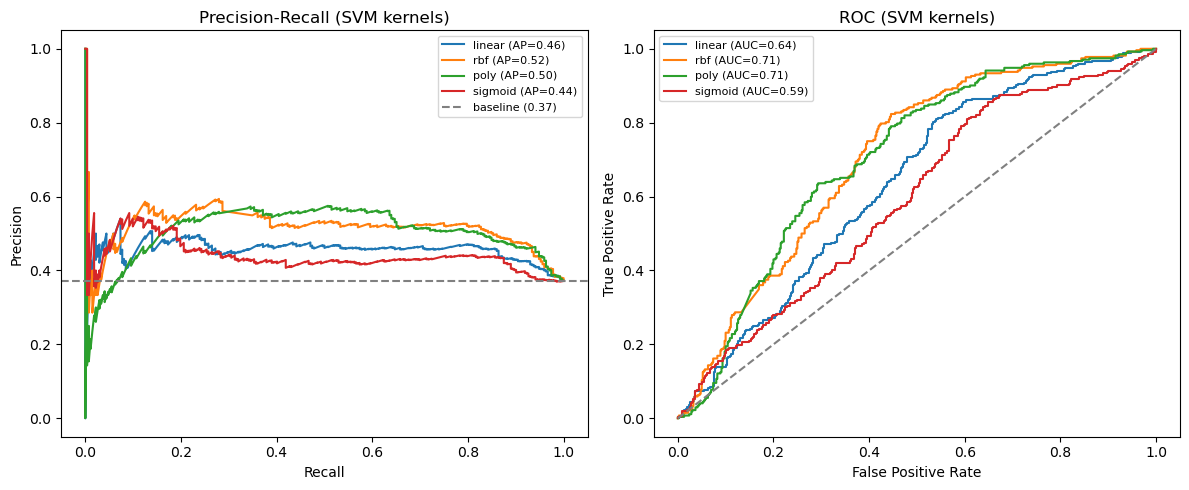

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for kernel, r in results.items():
    y_proba = r['model'].predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[0].plot(recall, precision, label=f'{kernel} (AP={ap:.2f})')

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'{kernel} (AUC={auc:.2f})')

baseline = y_test.mean()
axes[0].axhline(baseline, ls='--', color='grey', label=f'baseline ({baseline:.2f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall (SVM kernels)')
axes[0].legend(fontsize=8)

axes[1].plot([0, 1], [0, 1], ls='--', color='grey')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC (SVM kernels)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()